# <span style="color:blue">**Du score à la décision / From score to decision : Perceptron complet, sigmoïde et régression logistique**</span>

*Notebook d’accompagnement du **Blog Post 2** de la série **AI From Scratch / IA pas à pas***.

# <span style="color:blue">**Welcome & Objectives**</span>

Dans le notebook précédent, on a vu comment un perceptron simple combine plusieurs informations pour produire un **score**.

Ici, on change de type de problème.

Le but n’est plus de prédire une quantité continue, mais de comprendre comment un modèle peut transformer un score en **probabilité**, puis en **décision**.

Dans ce notebook, on va :

- rappeler pourquoi un score brut ne suffit pas pour les problèmes binaires ;
- introduire la **sigmoïde** ;
- construire le **perceptron complet** ;
- comprendre pourquoi la **loss** doit changer ;
- implémenter une **régression logistique** ;
- voir que d’autres **fonctions d’activation** existent aussi ;
- comprendre enfin pourquoi un seul neurone reste limité.

L’objectif ici est d’aller plus vite que dans le premier notebook :  
on garde les bases déjà acquises, et on se concentre sur ce qui change vraiment.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, classification_report
)

# <span style="color:#c8b6ff">**Rappel : le perceptron simple**</span>

Dans le notebook précédent, on a construit le **perceptron simple** :

$$
\hat{y} = w^\top x + b
$$

Son rôle est simple :

- il reçoit plusieurs variables d'entrée ;
- il leur applique des poids ;
- il additionne le tout avec un biais ;
- il produit un **score**.

Ce mécanisme fonctionne bien pour les problèmes de **régression**, quand on veut prédire une valeur continue.

Mais pour un problème binaire, un score brut ne suffit pas encore.

Epoch 000 => Loss: 486.6505
Epoch 005 => Loss: 154.1337
Epoch 010 => Loss: 133.5458
Epoch 015 => Loss: 131.9461
Epoch 020 => Loss: 131.5179
Epoch 025 => Loss: 131.1758
Epoch 030 => Loss: 130.8517
Epoch 035 => Loss: 130.5399
Epoch 040 => Loss: 130.2387
Epoch 045 => Loss: 129.9466
Epoch 050 => Loss: 129.6625
Epoch 055 => Loss: 129.3855
Epoch 060 => Loss: 129.1146
Epoch 065 => Loss: 128.8492
Epoch 070 => Loss: 128.5886
Epoch 075 => Loss: 128.3321
Epoch 080 => Loss: 128.0794
Epoch 085 => Loss: 127.8300
Epoch 090 => Loss: 127.5836
Epoch 095 => Loss: 127.3397


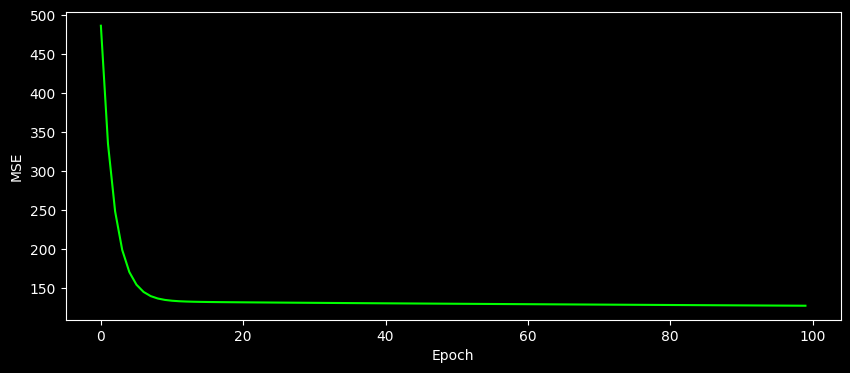

In [5]:
import sys, os #noqa
proj_root = os.path.abspath(os.path.join(os.getcwd(), ".."))  # ajuster le chemin si nécessaire
if proj_root not in sys.path:
    sys.path.insert(0, proj_root) 

from modules.bases import perceptron #noqa
from modules.utils import create_data #noqa

X, y = create_data(n=100)
w, b, _ = perceptron(X, y)

## <span style="color:#c8b6ff">**Pourquoi le score brut ne suffit plus**</span>

Le perceptron simple produit un **score brut**.

C’est très bien quand on veut prédire une quantité continue.  
Mais pour un problème binaire, ce score pose un problème :

- il peut être négatif ;
- il peut être supérieur à `1` ;
- il n’est donc **pas directement interprétable comme une probabilité**.

Or, pour décider entre **0** et **1**, on veut idéalement une sortie comprise entre `0` et `1`.

In [6]:
# Exemple : score brut produit par un perceptron simple

x = np.array([0.8, 0.6, 0.9])   # 3 signaux d'entrée
w = np.array([2.5, 1.8, 3.0])   # poids
b = -1.2                        # biais

score = x @ w + b
print(f"Score brut = {score:.3f}")

Score brut = 4.580


Ici, le modèle produit un **score**, pas encore une probabilité.

Si ce score vaut par exemple `4.580`, cela peut vouloir dire :
- “forte tendance vers la classe 1” ;
- mais certainement pas 458 % de chance”.

Le score est donc utile **en interne**, mais il faut encore le transformer pour obtenir une vraie sortie probabiliste.

In [7]:
# Plusieurs exemples de scores bruts

X_demo = np.array([
    [0.1, 0.2, 0.1],
    [0.8, 0.6, 0.9],
    [1.2, 0.9, 1.1]
])

w = np.array([2.5, 1.8, 3.0])
b = -1.2

scores = X_demo @ w + b

for i, s in enumerate(scores, start=1):
    print(f"Exemple {i} -> score brut = {s:.3f}")

Exemple 1 -> score brut = -0.290
Exemple 2 -> score brut = 4.580
Exemple 3 -> score brut = 6.720


On voit bien que les scores peuvent prendre des valeurs très différentes :

- parfois négatives ;
- parfois supérieures à `1` ;
- parfois très grandes.

C’est exactement pour cela qu’on a besoin d’une fonction qui **compresse** ce score dans l’intervalle `[0, 1]`.

C’est le rôle de la **sigmoïde**.

## <span style="color:#c8b6ff">**La sigmoïde**</span>

Pour transformer un score brut en probabilité, on utilise une fonction très simple :

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

Son rôle est de **compresser** n’importe quel score réel dans l’intervalle `[0, 1]`.

On peut la lire ainsi :

- si `z` est très négatif, la sortie est proche de `0` ;
- si `z = 0`, la sortie vaut `0.5` ;
- si `z` est très positif, la sortie est proche de `1`.

C’est cette fonction qui permet de passer du **score** à la **probabilité**.

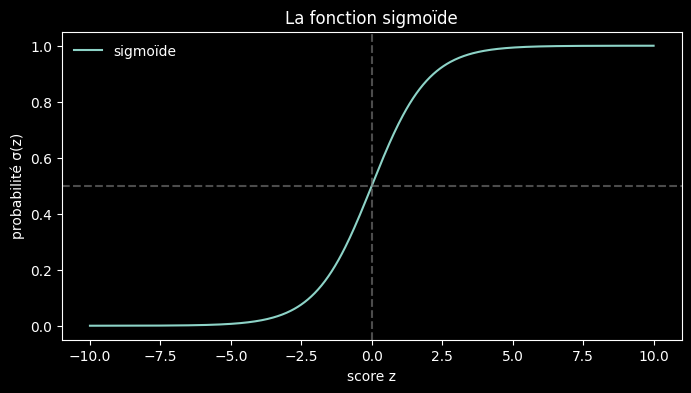

In [8]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Valeurs de z
z = np.linspace(-10, 10, 500)

# Valeurs transformées par la sigmoïde
sigma_z = sigmoid(z)

# Graphe
plt.figure(figsize=(8, 4))
plt.plot(z, sigma_z, label="sigmoïde")
plt.axhline(0.5, color="gray", linestyle="--", alpha=0.6)
plt.axvline(0, color="gray", linestyle="--", alpha=0.6)
plt.xlabel("score z")
plt.ylabel("probabilité σ(z)")
plt.title("La fonction sigmoïde")
plt.legend(edgecolor='none')
plt.show()

### Lecture rapide

Sur le graphe, on voit bien la logique :

- à gauche, les scores très négatifs sont écrasés vers `0` ;
- au centre, `z = 0` correspond à une probabilité de `0.5` ;
- à droite, les scores très positifs sont écrasés vers `1`.

La sigmoïde ne change donc pas l’ordre des scores :  
elle les **recalibre** pour les rendre interprétables comme des probabilités.

In [9]:
# Quelques exemples numériques

for value in [-5, -1, 0, 1, 5]:
    print(f"z = {value:>2}  ->  σ(z) = {sigmoid(value):.4f}")

z = -5  ->  σ(z) = 0.0067
z = -1  ->  σ(z) = 0.2689
z =  0  ->  σ(z) = 0.5000
z =  1  ->  σ(z) = 0.7311
z =  5  ->  σ(z) = 0.9933


## <span style="color:#c8b6ff">**Le perceptron complet**</span>

On peut maintenant assembler les deux briques :

1. le **score linéaire**
2. la **sigmoïde**

Le perceptron complet fonctionne donc en deux étapes :

### Étape 1: calculer le score

$$
z = w^\top x + b
$$

### Étape 2: transformer ce score en probabilité

$$
a = \sigma(z)
$$

où :

- `z` est le **score brut** ;
- `a` est la **sortie activée**, donc une probabilité comprise entre `0` et `1`.

Autrement dit, le modèle ne s'arrête plus à une somme pondérée.  
Il calcule d'abord un score, puis le passe dans une fonction d'activation.

C'est cette structure :

$$
x \rightarrow z = w^\top x + b \rightarrow a = \sigma(z)
$$

qui constitue ici le **perceptron complet**.

In [10]:
# Exemple : perceptron complet = score linéaire + sigmoïde

x = np.array([0.8, 0.6, 0.9])   # variables d'entrée
w = np.array([2.5, 1.8, 3.0])   # poids
b = -1.2                        # biais

# 1) score linéaire
z = x @ w + b

# 2) activation sigmoïde
a = sigmoid(z)

print(f"Score brut z       = {z:.4f}")
print(f"Probabilité a=σ(z) = {a:.4f}")

Score brut z       = 4.5800
Probabilité a=σ(z) = 0.9898


# <span style="color:#c8b6ff">**Le processus d'apprentissage**</span>

Dans le notebook précédent, on a déjà vu la structure générale de l’apprentissage :

1. initialiser les paramètres ;
2. produire une prédiction ;
3. mesurer l’erreur ;
4. calculer comment corriger ;
5. mettre à jour ;
6. recommencer.

Cette logique ne change pas.

Ce qui change ici, c’est **la forme de la sortie**, donc aussi :

- la façon de faire le **forward** ;
- la **loss** utilisée ;
- les **gradients** calculés.

Autrement dit, on garde la même boucle, mais on entre maintenant dans le cas du **perceptron complet**.

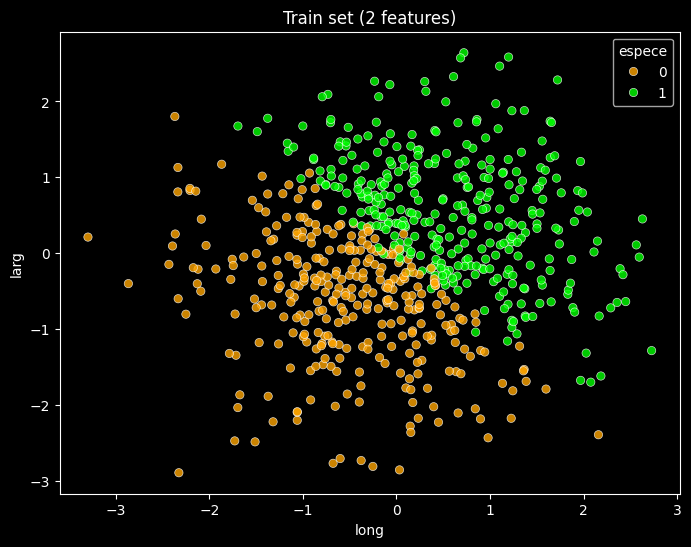

In [11]:
# ===========================================
# DONNEES QUI SERONT UTILISE DANS CE MODULE
# ===========================================
# Il s'agit ici d'un dataset d'espèces de plantes 
# dont on dispose de la longueur et de la largeur 
# des feuilles. Le but : developer un algo capable
# de differentier les differentes espces sur la 
# base des details sur les feuilles des plantes.
from modules.utils import create_class_dataset

X_train, y_train, X_test, y_test = create_class_dataset(n_features=2, class_sep=10.0)

df_plot = pd.DataFrame({
    "long": X_train[:, 0],
    "larg": X_train[:, 1],
    "espece": y_train
})

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_plot, x="long", y="larg", hue="espece", palette={1:"lime", 0:"orange"}, alpha=0.8)
plt.title("Train set (2 features)")
plt.show()

## <span style="color:#c8b6ff">**0. Initialisation**</span>

In [12]:
from modules.bases import initialization, update_parameters

W, b = initialization(X_train.shape[1])

## <span style="color:#c8b6ff">**1. Forward propagation**</span>

Dans le perceptron simple, le forward produisait directement un score :

$$
\hat{y} = w^\top x + b
$$

Ici, on ajoute une étape.

Le forward se fait maintenant en deux temps :

1. calculer le **score linéaire**
$$
z = w^\top x + b
$$

2. appliquer la **sigmoïde**
$$
a = \sigma(z)
$$

Le modèle ne renvoie donc plus directement un score brut, mais une **probabilité**.

In [13]:
def forward(X, W, b):
    z = W @ X.T + b
    a = 1 / (1 + np.exp(-z))
    return a

## <span style="color:#c8b6ff">**2. Loss**</span>

C’est ici que le changement devient vraiment important.

Dans le notebook précédent, on utilisait la **MSE**, car on prédisait une valeur continue.  
Mais ici, la sortie du modèle est une **probabilité**.

On ne veut donc plus seulement mesurer un écart numérique entre deux valeurs.  
On veut mesurer à quel point la probabilité prédite est **cohérente avec ce qui s’est réellement passé**.

C’est pour cela qu’on utilise la **log-loss** :

$$
L = - \frac{1}{n} \sum_{i=1}^{n}
\left[
y_i \log(a_i) + (1-y_i)\log(1-a_i)
\right]
$$

Cette loss pénalise fortement les cas où le modèle est très confiant… mais dans la mauvaise direction.

### Intuition

- si `y = 1` et que le modèle prédit une probabilité proche de `1`, la loss est faible ;
- si `y = 1` et que le modèle prédit une probabilité proche de `0`, la loss devient grande ;
- même logique pour `y = 0`.

In [14]:
def log_loss(y, a, eps=1e-8):
    y = np.ravel(y)
    # on ajoute eps pour eviter un a = 0 et provoquer un log(0)=>!error!
    return -np.mean(y * np.log(a + eps) + (1 - y) * np.log(1 - a + eps))

## <span style="color:#c8b6ff">**3. Gradients**</span>

Une fois la loss calculée, il faut savoir comment corriger les paramètres.

Le principe reste le même : on cherche à savoir **dans quelle direction modifier `w` et `b` pour faire baisser la loss**.

Mais cette fois, la sortie du modèle passe par une sigmoïde. Les gradients doivent donc tenir compte de cette étape supplémentaire.

La logique est la suivante :

- la loss dépend de la probabilité prédite `a`
- `a` dépend du score `z`
- `z` dépend des poids `w` et du biais `b`

On applique donc la **règle de chaîne**. Le résultat final est donc :

$$
\frac{\partial L}{\partial w} = \frac{1}{n} X^\top (a - y)
$$

$$
\frac{\partial L}{\partial b} = \frac{1}{n} \sum (a - y)
$$

### Intuition

Le terme `(a - y)` mesure l’écart entre :

- ce que le modèle croit ;
- ce qui s’est réellement passé.

Si cet écart est grand, la correction sera forte. S’il est petit, la correction sera faible.

In [15]:
def gradients(X, y, a):
    """
    Cette fonction calcule les gradients de la Log-Loss
    """
    n = len(y)
    dL_da = 2 * (a - y) / n
    dw = np.dot(dL_da, X)
    db = np.sum(dL_da)
    return dw, db

## <span style="color:#c8b6ff">**4. Update**</span>

$$
w \leftarrow w - \alpha \, dw
$$

$$
b \leftarrow b - \alpha \, db
$$

où `alpha` est le learning rate.

## <span style="color:#c8b6ff">**5. Boucle d'apprentissage**</span>

In [16]:
from tqdm import tqdm

def artificial_neuron(X, y, learning_rate=0.001, epochs=100, plot=True):
    # 1) Initialisation des poids et du biais
    features = X.shape[1]
    W, b = initialization(features)

    Losses = [] # pour pouvoir enregistrer notre loss
    Acc    = []
    
    for epoch in tqdm(range(epochs)): # les epochs sont les itération du modèle sur ttes nos data
        # 2) Prédiction
        a = forward(X, W, b)

        # 3) Calcul de la loss et de la prediction
        error = log_loss(y, a)
        Losses.append(error)
        
        y_pred = a >= 0.5
        accuracy = accuracy_score(y, y_pred)
        Acc.append(accuracy)

        # 4) Calcul des gradients
        dW, db = gradients(X, y, a)

        # 5) Mise à jour des paramètres
        W, b = update_parameters(W, b, dW, db, learning_rate)

        # if epoch % 5 == 0:
        #     print(f"Epoch {epoch:03d} => Loss: {error:.4f}")

    if plot:
        plt.style.use("dark_background")
        plt.figure(figsize=(10, 4))
        _, ax = plt.subplots(1, 2, figsize=(18, 6))
        ax[0].plot(Losses, color='lime')
        ax[0].set_xlabel("Epoch")
        ax[0].set_ylabel("Log-Loss")
        
        ax[1].plot(Acc, color='skyblue')
        ax[1].set_xlabel("Epoch")
        ax[1].set_ylabel("Accuracy")
        plt.show()
    
    return W, b, Losses, Acc

def predict(X, W, b, diagnose=True, y=None):
    pred_proba = forward(X, W, b)
    pred_labels = pred_proba >= 0.5 # pour retourner 1 si la proba >= 0.5 et 0 sinon
    
    if diagnose:
        if y is None:
            raise(ValueError("y doit être fournis"))
        accuracy = accuracy_score(y, pred_labels)
        print(f"Précision du model : {accuracy}")
    return pred_proba, pred_labels

100%|██████████| 10000/10000 [00:05<00:00, 1799.42it/s]


<Figure size 1000x400 with 0 Axes>

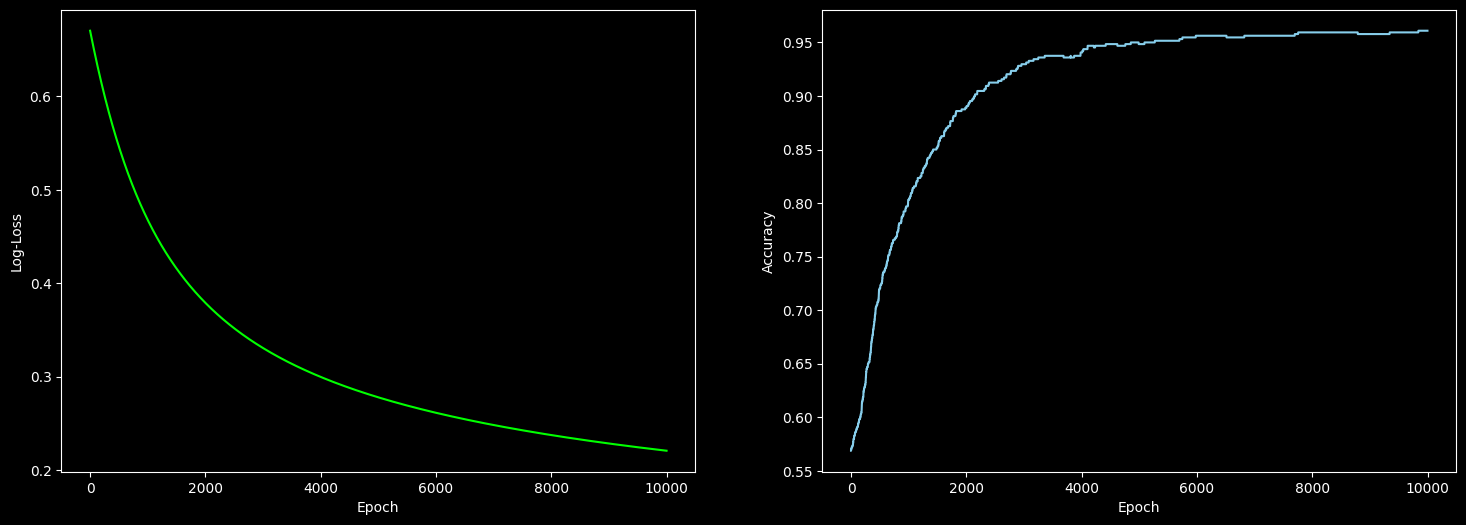

EVALUATION DU MODEL (Test set)
Précision du model : 0.93125
              precision    recall  f1-score   support

           0       0.95      0.91      0.93        78
           1       0.92      0.95      0.93        82

    accuracy                           0.93       160
   macro avg       0.93      0.93      0.93       160
weighted avg       0.93      0.93      0.93       160



In [17]:
W, b, Loss, Acc = artificial_neuron(X_train, y_train, epochs=10000)

print("="*40)
print("EVALUATION DU MODEL (Test set)")
print("="*40)
proba_pred, y_pred = predict(X_test, W, b, y=y_test)
print(classification_report(y_test, y_pred))

### Lecture des résultats

On observe ici deux choses importantes :

- la **log-loss diminue régulièrement**, ce qui montre que le modèle apprend de manière stable ;
- l’**accuracy augmente puis se stabilise**, ce qui indique que la séparation entre les deux classes s'améliore au fil des epochs.

Le rapport de classification confirme que le modèle fonctionne bien :

- la **précision** est élevée ;
- le **rappel** est bon pour les deux classes ;
- le **F1-score** est équilibré ;
- l’**accuracy globale** dépasse `93 %`.

Autrement dit, notre neurone artificiel parvient ici à transformer correctement un score en probabilité, puis une probabilité en décision binaire.

> **Remarque**  
> On voit que l’accuracy finit par se stabiliser, alors que la log-loss continue encore à baisser.  
> Cela signifie que le modèle ne change plus beaucoup ses décisions finales, mais continue à améliorer la qualité de ses probabilités.

## <span style="color:#c8b6ff">**Implémentation avec scikit-learn**</span>

Jusqu'ici, on a construit la régression logistique **from scratch** pour comprendre la mécanique interne :

- score linéaire ;
- sigmoïde ;
- log-loss ;
- gradients ;
- mise à jour des paramètres.

En pratique, on utilise souvent une bibliothèque comme **scikit-learn**, qui fournit déjà une implémentation robuste et optimisée.

L'idée reste exactement la même :

- apprendre des poids ;
- apprendre un biais ;
- produire des probabilités ;
- convertir ces probabilités en décisions.

In [18]:
from sklearn.linear_model import LogisticRegression

# -----------------------------
# 1) TRAIN / TEST
# -----------------------------
# X_train, y_train, X_test, y_test

# -----------------------------
# 2) MODELE
# -----------------------------
model = LogisticRegression()
model.fit(X_train, y_train)

# -----------------------------
# 3) PARAMETRES APPRIS
# -----------------------------
print("Paramètres appris :\n")
print(f'{"Biais (intercept)":<22} : {model.intercept_[0]:+.4f}')

for nom, coef in zip(["long", "larg"], model.coef_[0]):
    print(f"{nom:<22} : {coef:+.4f}")

# -----------------------------
# 4) PREDICTIONS
# -----------------------------
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# -----------------------------
# 5) EVALUATION
# -----------------------------
acc = accuracy_score(y_test, y_pred)

print("\n==============================")
print("EVALUATION DU MODELE (Test set)")
print("==============================")
print(f"Accuracy : {acc:.5f}\n")
print(classification_report(y_test, y_pred))

Paramètres appris :

Biais (intercept)      : -0.0299
long                   : +4.6846
larg                   : +5.0138

EVALUATION DU MODELE (Test set)
Accuracy : 0.93750

              precision    recall  f1-score   support

           0       0.95      0.92      0.94        78
           1       0.93      0.95      0.94        82

    accuracy                           0.94       160
   macro avg       0.94      0.94      0.94       160
weighted avg       0.94      0.94      0.94       160



### Lecture rapide

On retrouve ici les mêmes objets qu'avant :

- un **biais** ;
- des **poids** ;
- des **probabilités** ;
- puis des **décisions binaires**.

La différence, c'est que toute la partie optimisation est maintenant prise en charge par la librairie.

Autrement dit :

- l'implémentation from scratch sert à **comprendre** ;
- scikit-learn sert à **aller plus vite et travailler proprement**.

> **À retenir**  
> `LogisticRegression` ne change pas le modèle de fond.  
> Elle automatise simplement son entraînement avec une implémentation plus robuste que notre version pédagogique faite à la main.

## <span style="color:#c8b6ff">**Autres fonctions d’activation**</span>

La sigmoïde est très utile pour transformer un score en probabilité dans un problème binaire.  
Mais ce n’est pas la seule fonction d’activation.

En pratique, il en existe plusieurs, chacune avec un rôle différent.

### Quelques exemples

- **Sigmoïde**
  - sortie entre `0` et `1`
  - utile pour la **classification binaire**

- **Softmax**
  - transforme plusieurs scores en probabilités qui somment à `1`
  - utile pour la **classification multiclasse**

- **ReLU**
  - garde les valeurs positives et met les négatives à `0`
  - très utilisée dans les **couches cachées** des réseaux de neurones

- **GELU / SiLU**
  - variantes plus récentes
  - souvent utilisées dans des architectures modernes comme les transformers

### Idée à retenir

Une fonction d’activation sert à **transformer une sortie linéaire** en quelque chose de plus utile :

- une probabilité ;
- une décision ;
- ou une représentation non linéaire plus riche.

Autrement dit, elle permet au modèle d’aller **au-delà d’une simple somme pondérée**.

In [19]:
# Quelques activations simples en numpy

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

def softmax(z):
    exp_z = np.exp(z - np.max(z))
    return exp_z / np.sum(exp_z)

z = np.array([-2.0, 0.5, 1.5])

print("z :", z)
print("sigmoid :", sigmoid(z))
print("relu    :", relu(z))
print("softmax :", softmax(z))

z : [-2.   0.5  1.5]
sigmoid : [0.11920292 0.62245933 0.81757448]
relu    : [0.  0.5 1.5]
softmax : [0.02159923 0.26313249 0.71526828]


## <span style="color:#c8b6ff">**Limites du perceptron**</span>

Jusqu'ici, notre neurone fonctionnait bien sur des données relativement simples.

Mais un perceptron, même complet avec sa sigmoïde, reste fondamentalement limité : il ne peut apprendre qu'une **frontière de décision simple**.

Pour le voir, on peut créer un jeu de données où les deux classes s'enroulent l'une autour de l'autre.

Dans ce cas :

- les classes sont bien séparables visuellement ;
- mais pas par une simple droite ;
- un neurone seul ne suffit donc plus.

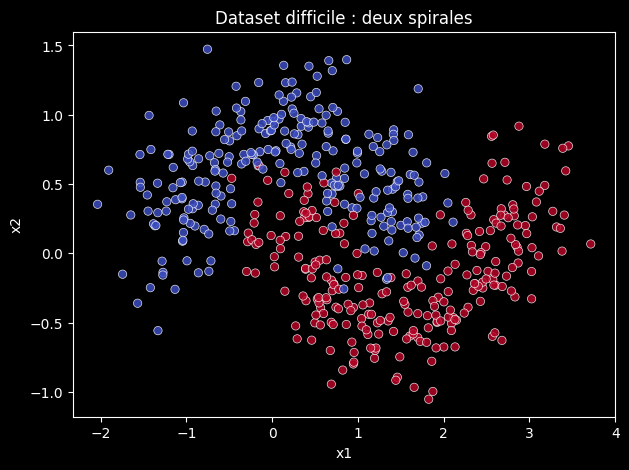

In [20]:
from modules.utils import create_moons_dataset

df_hard = create_moons_dataset(n_samples=500, noise=0.25, rotate_deg=2)

plt.figure(figsize=(7, 5))
plt.scatter(
    df_hard["x1"],
    df_hard["x2"],
    c=df_hard["target"],
    cmap="coolwarm",
    edgecolors="white",
    linewidths=0.5,
    alpha=0.85
)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Dataset difficile : deux spirales")
plt.show()

100%|██████████| 10000/10000 [00:05<00:00, 1771.58it/s]


<Figure size 1000x400 with 0 Axes>

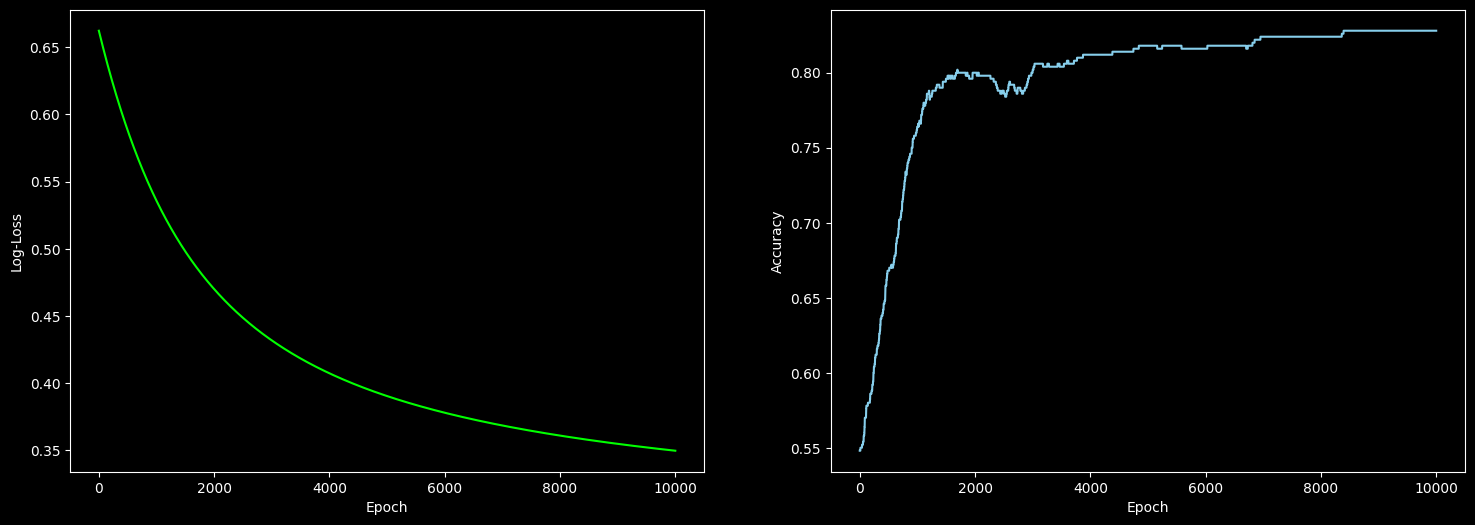

Précision du model : 0.828
              precision    recall  f1-score   support

           0       0.84      0.82      0.83       250
           1       0.82      0.84      0.83       250

    accuracy                           0.83       500
   macro avg       0.83      0.83      0.83       500
weighted avg       0.83      0.83      0.83       500



In [21]:
X_hard = df_hard[["x1", "x2"]].to_numpy(dtype=float)
y_hard = df_hard["target"].to_numpy(dtype=int)

# Ici, on réentraine notre neurone sur ce dataset et on prédit

w_hard, b_hard, Loss_hard, Acc_hard = artificial_neuron(X_hard, y_hard, epochs=10000)

proba_hard, y_pred_hard = predict(X_hard, w_hard, b_hard, y=y_hard)
print(classification_report(y_hard, y_pred_hard))

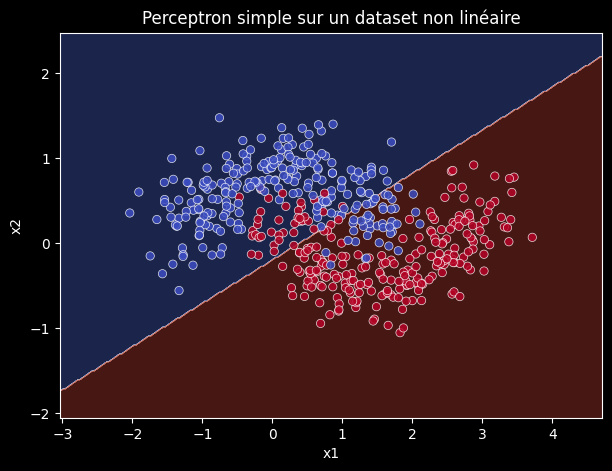

In [22]:
def plot_decision_boundary(X, y, w, b, model_predict_proba, title="Frontière de décision"):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    proba = model_predict_proba(grid, w, b)
    Z = (proba >= 0.5).astype(int).reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.35, cmap="coolwarm")
    plt.scatter(
        X[:, 0], X[:, 1],
        c=y,
        cmap="coolwarm",
        edgecolors="white",
        linewidths=0.5,
        alpha=0.85
    )
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.show()

plot_decision_boundary(
    X_hard,
    y_hard,
    w_hard,
    b_hard,
    model_predict_proba=forward,
    title="Perceptron simple sur un dataset non linéaire"
)

### Ce qu'on observe

Le modèle échoue ici non pas parce qu'il apprend mal,  
mais parce que sa structure est trop simple.

Autrement dit :

- le problème n'est pas seulement le choix des poids ;
- le problème est la **forme de la frontière de décision**.

C'est exactement pour cela qu'on a besoin de plusieurs neurones organisés en couches :

> Un seul neurone trace une frontière simple,  
> Plusieurs neurones peuvent composer des frontières beaucoup plus riches.

C'est la porte d'entrée vers le **multilayer perceptron**.

## <span style="color:#c8b6ff">**Cas d'application : prédire le churn d'une plateforme numérique**</span>

Jusqu'ici, on a surtout travaillé sur des exemples pédagogiques pour comprendre la mécanique de la régression logistique.

Passons maintenant à un cas plus concret et plus proche d’un usage réel :

> **prédire si un utilisateur va quitter une plateforme numérique**.

Ce problème est très courant aujourd’hui :

- applications mobiles ;
- plateformes de streaming ;
- services SaaS ;
- abonnements digitaux.

Ici, la cible est binaire :

- `1` → l’utilisateur churn ;
- `0` → l’utilisateur reste.

Nous allons :

1. charger un dataset de **20 000 utilisateurs** ;
2. faire un peu de **feature engineering** ;
3. entraîner une **régression logistique** sur `70 %` des données ;
4. évaluer le modèle sur les `30 %` restants.

L’objectif n’est plus seulement de comprendre la formule, mais de voir comment cette logique s’insère dans un mini pipeline de données plus réaliste.

In [23]:
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

In [24]:
# ============================================================
# 1) IMPORTER LE DATASET
# ============================================================

df = pd.read_csv("dataset_streaming_churn.csv")

print("\nDataset chargé :")
display(df.head())
print("\nTaux de churn :", df["target"].mean().round(4))

# ============================================================
# 2) FEATURE ENGINEERING
# ============================================================
# On ajoute quelques variables dérivées simples mais parlantes

df["engagement_score"] = (
    0.4 * df["watch_hours_week"]
    + 0.4 * df["sessions_week"]
    + 20 * df["content_completion_rate"]
)

df["friction_score"] = (
    1.5 * df["support_tickets_90d"]
    + 2.5 * df["payment_failures_6m"]
    + 0.08 * df["days_since_last_login"]
)

df["price_per_hour"] = df["monthly_price"] / (df["watch_hours_week"] + 1)

# ============================================================
# 3) TRAIN / TEST SPLIT (70 / 30)
# ============================================================

X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("\nTrain shape :", X_train.shape)
print("Test shape  :", X_test.shape)

print("\nRépartition de la cible :")
vals, counts = np.unique(y_train, return_counts=True)
print(dict(zip(vals, counts / counts.sum())))

# ============================================================
# 4) PREPROCESSING
# ============================================================

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")), # Pour imputer les valeurs manquantes numériques par la mediane
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")), # Pour imputer les valeurs manquantes catégorielles par le mode
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# ============================================================
# 5) MODELE : LOGISTIC REGRESSION
# ============================================================

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000, random_state=42))
])

# ============================================================
# CROSS-VALIDATION
# ============================================================
# Pourquoi faire ça ?
# Un simple split train/test dépend d'un seul découpage des données.
# La cross-validation permet de répéter l'entraînement sur plusieurs
# sous-ensembles pour obtenir une estimation plus robuste des performances.

# Ici, on utilise une validation croisée stratifiée :
# - "stratifiée" = on garde à peu près la même proportion de classes
#   dans chaque fold
# - "5 folds" = on découpe les données d'entraînement en 5 morceaux
#   puis on entraîne/valide 5 fois en changeant la partie de validation

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# On calcule ici l'accuracy sur chaque fold
cv_scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("\n==============================")
print("CROSS-VALIDATION (train set)")
print("==============================")
print("Scores par fold :", np.round(cv_scores, 4))
print(f"Accuracy moyenne : {cv_scores.mean():.4f}")
print(f"Ecart-type       : {cv_scores.std():.4f}")

model.fit(X_train, y_train) # On réentraine

# ============================================================
# 6) PREDICTIONS + METRICS
# ============================================================

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("\n==============================")
print("EVALUATION LOGISTIC REGRESSION")
print("==============================")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_proba):.4f}")
print("\nClassification report :")
print(classification_report(y_test, y_pred))
print("Confusion matrix :")
print(confusion_matrix(y_test, y_pred))


Dataset chargé :


,age,tenure_months,monthly_price,watch_hours_week,sessions_week,support_tickets_90d,ads_seen_week,payment_failures_6m,days_since_last_login,recommendation_click_rate,content_completion_rate,avg_rating_given,plan_type,device_main,payment_method,autopay_enabled,student_discount,family_account,target
0,22,3,7.686911,0.099475,6,0,17,0,42,0.194392,0.692425,5.000000,standard,tv,card,1,0,0,0
1,59,44,13.411246,1.070923,8,2,20,0,12,0.214363,0.353591,4.116251,basic,mobile,bank_transfer,1,0,0,0
2,52,13,7.996396,10.796421,7,1,16,0,31,0.553210,0.562885,4.890474,basic,mobile,card,1,0,0,0
3,41,43,23.156155,7.638078,4,1,19,1,43,0.102286,0.643014,4.777000,standard,tv,card,1,0,0,0
4,40,34,15.839965,3.430053,4,0,16,0,45,0.339850,0.744158,3.787531,basic,tablet,bank_transfer,0,0,0,0



Taux de churn : 0.0624

Train shape : (14000, 21)
Test shape  : (6000, 21)

Répartition de la cible :
{0: 0.9376428571428571, 1: 0.062357142857142854}


c:\Users\aurel\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
2 fits failed out of a total of 5.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\aurel\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\aurel\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\aurel\AppData\L


CROSS-VALIDATION (train set)
Scores par fold : [   nan 0.9389 0.9357    nan 0.9364]
Accuracy moyenne : nan
Ecart-type       : nan

EVALUATION LOGISTIC REGRESSION
Accuracy : 0.9392
ROC AUC  : 0.8162

Classification report :
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      5626
           1       0.76      0.03      0.07       374

    accuracy                           0.94      6000
   macro avg       0.85      0.52      0.52      6000
weighted avg       0.93      0.94      0.91      6000

Confusion matrix :
[[5622    4]
 [ 361   13]]


### <span style="color:#c8b6ff">**Lecture des résultats**</span>

Les résultats montrent un cas très classique en classification déséquilibrée.

Le modèle obtient une **accuracy élevée** (`0.9392`) et une **cross-validation stable** (`0.9369 ± 0.0014`).  
Cela signifie que le pipeline est globalement cohérent et que les performances varient peu selon le découpage des données.

Mais il faut interpréter ces chiffres avec prudence.

Ici, le taux de churn est très faible (`6.24 %`).  
Autrement dit, la grande majorité des utilisateurs appartiennent à la classe `0`.  
Dans ce contexte, une accuracy élevée ne garantit pas que le modèle détecte bien les churners.

C’est exactement ce qu’on observe :

- la classe `0` est très bien prédite ;
- la classe `1` est très mal détectée ;
- le **recall** de la classe churn vaut seulement `0.03`.

Autrement dit, le modèle identifie très peu de churners, même s’il se trompe rarement quand il en prédit un.

Le **ROC AUC = 0.8162** montre pourtant que le modèle capte un signal réel :  
il sait assez bien classer les individus du plus risqué au moins risqué.  
Le problème vient donc moins de la capacité du modèle à apprendre que de la **règle de décision** utilisée ici.

### Ce qu'il faut retenir

Ce modèle constitue une bonne première base, mais il n'est pas encore suffisant pour un usage métier de rétention client.

Dans un vrai cas de churn, on chercherait probablement à :

- ajuster le **seuil de décision** ;
- mieux gérer le **déséquilibre de classes** ;
- ou optimiser la métrique en fonction du coût métier des faux négatifs et des faux positifs.

# <span style="color:#c8b6ff">**Conclusion**</span>

Dans ce notebook, on a franchi une étape importante.

On est parti du **perceptron simple**, qui produit un score linéaire, puis on a vu pourquoi ce score brut ne suffisait plus dès qu’on voulait répondre à une question binaire.  
Pour passer du score à une décision exploitable, on a ajouté une **fonction d’activation** : ici, la **sigmoïde**.

C’est ce changement qui fait apparaître quelque chose de plus général que la seule régression logistique :

> un **neurone artificiel**.

Autrement dit, un neurone n’est pas une idée abstraite ou mystérieuse.  
C’est une structure simple qui assemble :

- une **partie linéaire** ;
- un **biais** ;
- une **fonction d’activation** ;
- une **loss adaptée** ;
- un mécanisme d’apprentissage par **gradient descent**.

Dans ce chapitre, ce neurone a pris la forme d’un **neurone sigmoïde**, ce qui en fait naturellement un bon outil pour la **classification binaire** et donc pour la **régression logistique**.

Mais la vraie idée à retenir est plus large :

- on peut changer l’activation ;
- on peut changer la loss ;
- on peut changer le type de sortie ;
- et donc faire émerger différents comportements à partir d’une même brique de base.

La régression logistique n’est donc pas le point final.  
C’est surtout une **première incarnation complète du neurone artificiel**.

Et cette brique, une fois comprise, ouvre directement la suite :

> si un neurone peut déjà transformer des signaux en probabilité, alors plusieurs neurones organisés en couches pourront apprendre des relations beaucoup plus riches.

C’est exactement ce qui nous conduira vers le **multilayer perceptron**.